# Classification with Pipeline, KNN and make_moons

## Objective
Build a scikit-learn Pipeline that :
1. Generates non-linear data with make_moons
2. Scales features with StandardScaler
3. Classifies with K-Nearest Neighbors (KNN)

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)

## 2. Generate Data with make_moons

In [2]:
X, y = make_moons(n_samples=2000, noise=0.3, random_state=42)
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")

X shape : (2000, 2)
y shape : (2000,)
Classes : [0 1]


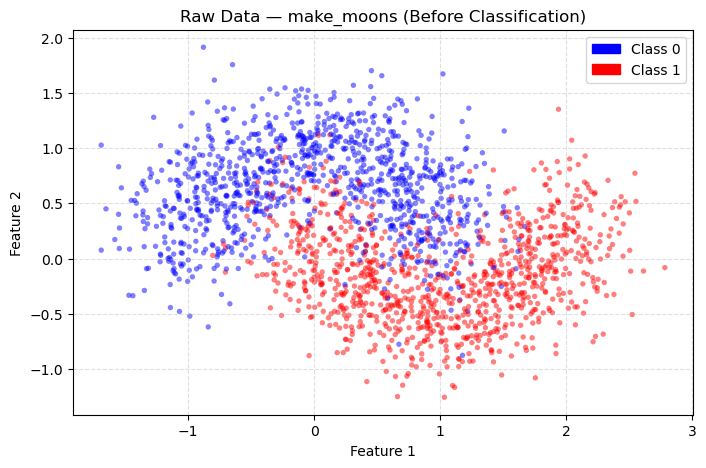

In [3]:
colors = ['blue' if label == 0 else 'red' for label in y]

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=colors, s=15, alpha=0.5, edgecolors='none')
plt.title("Raw Data — make_moons (Before Classification)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
blue_patch  = mpatches.Patch(color='blue',  label='Class 0')
red_patch   = mpatches.Patch(color='red',   label='Class 1')
plt.legend(handles=[blue_patch, red_patch])
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## 3. Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size : {X_train.shape[0]} samples")
print(f"Test  size : {X_test.shape[0]}  samples")

Train size : 1600 samples
Test  size : 400  samples


## 4. Build the Pipeline

In [5]:
pipeline = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])
print(pipeline)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])


## 5. Train & Evaluate

In [6]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print()
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

Accuracy : 0.9000 (90.00%)

              precision    recall  f1-score   support

     Class 0       0.89      0.90      0.90       197
     Class 1       0.91      0.90      0.90       203

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



## 6. Predict a New Datapoint

In [7]:
new_point = np.array([[0.5, 0.0]])
predicted_class = pipeline.predict(new_point)
proba = pipeline.predict_proba(new_point)

print(f"New datapoint : {new_point[0]}")
print(f"Predicted class : {predicted_class[0]}")
print(f"Probabilities   : Class 0 = {proba[0][0]:.2f}, Class 1 = {proba[0][1]:.2f}")

New datapoint : [0.5 0. ]
Predicted class : 1
Probabilities   : Class 0 = 0.20, Class 1 = 0.80


## 7. Visualise Decision Boundary + New Datapoint

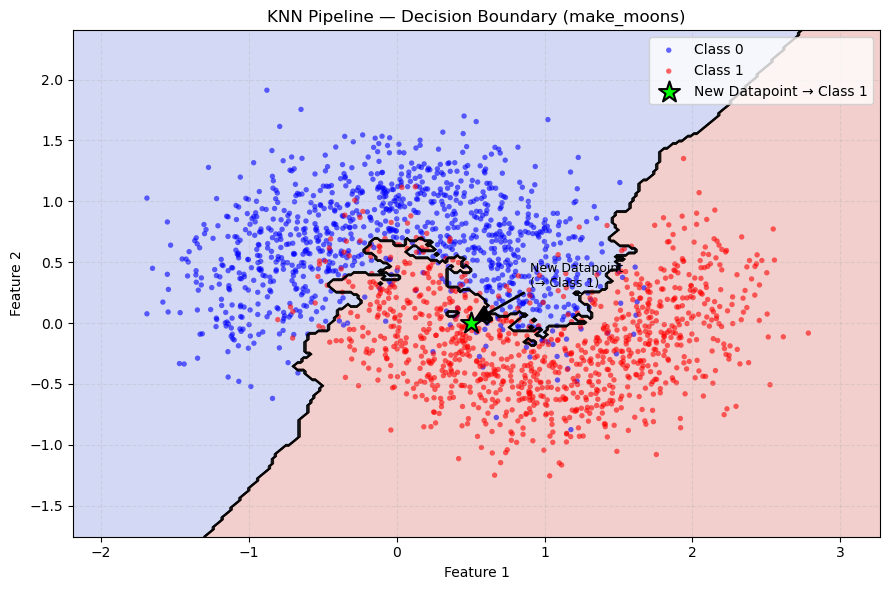

In [8]:
def plot_decision_boundary(pipeline, X, y, new_point=None, title="KNN Decision Boundary"):
    h = 0.02  # step size
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = pipeline.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(9, 6))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    plt.contour(xx, yy, Z, colors='k', linewidths=0.5)

    colors_map = {0: 'blue', 1: 'red'}
    for cls in [0, 1]:
        mask = y == cls
        plt.scatter(X[mask, 0], X[mask, 1], c=colors_map[cls], s=15, alpha=0.6, edgecolors='none', label=f'Class {cls}')

    if new_point is not None:
        pred = pipeline.predict(new_point)[0]
        plt.scatter(new_point[0, 0], new_point[0, 1], c='lime', s=250, marker='*', edgecolors='black', linewidths=1.5, zorder=5, label=f'New Datapoint → Class {pred}')
        plt.annotate(f'New Datapoint\n(→ Class {pred})', xy=(new_point[0, 0], new_point[0, 1]), xytext=(new_point[0, 0] + 0.4, new_point[0, 1] + 0.3), fontsize=9, arrowprops=dict(facecolor='black', shrink=0.05, width=1))

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_decision_boundary(pipeline, X, y,new_point=new_point, title="KNN Pipeline — Decision Boundary (make_moons)")

## 8. Tune K (Find the Best Number of Neighbors)

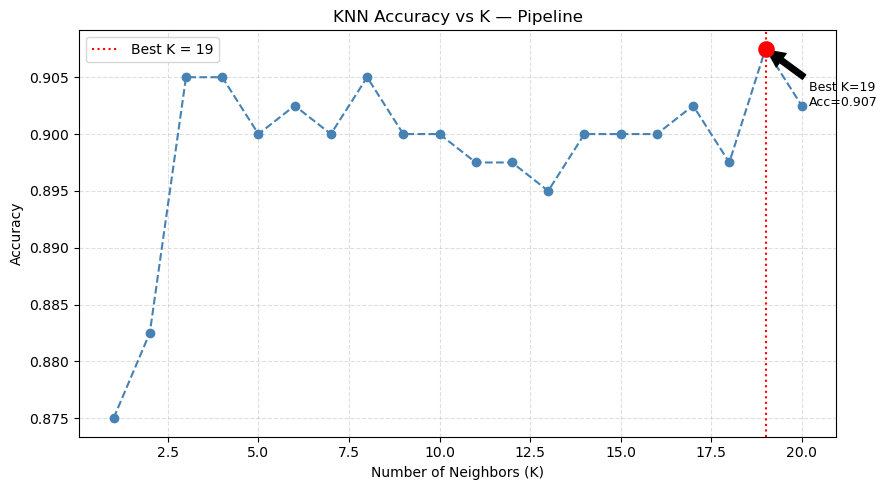

Best K = 19  |  Accuracy = 90.75%


In [9]:
k_range = range(1, 21)
accuracies = []

for k in k_range:
    pipe_k = Pipeline([('scaler', StandardScaler()), ('knn',    KNeighborsClassifier(n_neighbors=k))])
    pipe_k.fit(X_train, y_train)
    acc_k = accuracy_score(y_test, pipe_k.predict(X_test))
    accuracies.append(acc_k)

best_k = k_range[np.argmax(accuracies)]
best_acc = max(accuracies)

plt.figure(figsize=(9, 5))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='steelblue')
plt.axvline(x=best_k, color='red', linestyle=':', label=f'Best K = {best_k}')
plt.scatter([best_k], [best_acc], color='red', s=120, zorder=5)
plt.annotate(f'Best K={best_k}\nAcc={best_acc:.3f}', xy=(best_k, best_acc), xytext=(best_k + 1.2, best_acc - 0.005), fontsize=9, arrowprops=dict(facecolor='black', shrink=0.05))
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K — Pipeline')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Best K = {best_k}  |  Accuracy = {best_acc*100:.2f}%")